In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import nbinom

# ── Load Q1 betting predictions ──────────────────────────────────────────────
preds = pd.read_csv('q1_betting_match_predictions.csv', parse_dates=['date_time'])
prices = pd.read_csv('corners_prices.csv', parse_dates=['date_time'])
results = pd.read_csv('corners_prices_results.csv')

preds = preds.merge(results[['match_id','home_corners','away_corners']], on='match_id', how='left')
print(preds.shape, prices.shape)
preds.head(3)


(1911, 14) (5406, 11)


,match_id,date_time,competition_id,season_id,home_corners_x,away_corners_x,partition,pred_home_corners,pred_away_corners,pred_corner_diff,sigma2_home,sigma2_away,home_corners_y,away_corners_y
0,12450741,2024-08-09 19:00:00,346,189951,3,6,A,4.955064,4.006195,0.948868,7.780928,7.760536,3.0,6.0
1,12450740,2024-08-09 19:00:00,346,189951,1,9,A,5.182388,4.022708,1.159679,8.224846,6.608264,1.0,9.0
2,12449959,2024-08-10 11:30:00,346,189951,4,4,A,5.117897,4.349914,0.767983,7.462206,7.139825,4.0,4.0


In [2]:
def nb_params(mu, sigma2):
    """Convert (mu, sigma^2) -> (n, p) for scipy.stats.nbinom."""
    sigma2 = np.maximum(sigma2, mu + 1e-6)   # enforce sigma^2 > mu
    p = mu / sigma2
    n = mu * p / (1 - p)
    return n, p


def p_total_over(mu_h, sig2_h, mu_a, sig2_a, line):
    """P(home_corners + away_corners > line) via convolution."""
    max_k = int(mu_h + mu_a + 6 * (sig2_h + sig2_a)**0.5) + 1
    max_k = max(max_k, int(line) + 20)
    ks = np.arange(0, max_k + 1)
    n_h, p_h = nb_params(mu_h, sig2_h)
    n_a, p_a = nb_params(mu_a, sig2_a)
    pmf_h = nbinom.pmf(ks, n_h, p_h)
    pmf_a = nbinom.pmf(ks, n_a, p_a)
    pmf_total = np.convolve(pmf_h, pmf_a)[:2 * max_k + 1]
    total_ks = np.arange(len(pmf_total))
    return float(pmf_total[total_ks > line].sum())


def p_total_under(mu_h, sig2_h, mu_a, sig2_a, line):
    return 1.0 - p_total_over(mu_h, sig2_h, mu_a, sig2_a, line)


def p_diff_outcome(mu_h, sig2_h, mu_a, sig2_a, line, direction):
    """P(home - away >/</= line) via cross-correlation of PMFs."""
    max_k = int(max(mu_h, mu_a) + 5 * max(sig2_h, sig2_a)**0.5) + 1
    max_k = max(max_k, abs(int(line)) + 20)
    ks = np.arange(0, max_k + 1)
    n_h, p_h = nb_params(mu_h, sig2_h)
    n_a, p_a = nb_params(mu_a, sig2_a)
    pmf_h = nbinom.pmf(ks, n_h, p_h)
    pmf_a = nbinom.pmf(ks, n_a, p_a)
    # diff PMF: P(H-A = d) for d in [-max_k, max_k]
    full_conv = np.convolve(pmf_h, pmf_a[::-1])
    diff_ks = np.arange(-(max_k), max_k + 1)
    if direction == 'home':    # home wins handicap (H - A > line)
        return float(full_conv[diff_ks > line].sum())
    elif direction == 'away':  # away wins handicap (H - A < line)
        return float(full_conv[diff_ks < line].sum())
    else:                       # push (H - A == line)
        return float(full_conv[diff_ks == line].sum())


print("NB utilities defined.")


NB utilities defined.


In [3]:
def compute_ev(row, preds_map):
    """Return model probability and EV for a single bet row."""
    mid = int(row['match_id'])
    if mid not in preds_map:
        return np.nan, np.nan

    p = preds_map[mid]
    mu_h, mu_a = p['pred_home_corners'], p['pred_away_corners']
    s2_h, s2_a = p['sigma2_home'], p['sigma2_away']
    otype = row['odds_type']

    # Decimal odds: oh=home/over, oa=away/under, od=draw
    oh, oa, od = row['oh'], row['oa'], row['od']

    if otype == 'OU':
        line = float(row['gameweek'])     # OU line stored in gameweek column
        p_over  = p_total_over(mu_h, s2_h, mu_a, s2_a, line)
        p_under = 1.0 - p_over
        ev_over  = p_over  * oh - 1 if not np.isnan(oh) else np.nan
        ev_under = p_under * oa - 1 if not np.isnan(oa) else np.nan
        return (p_over, p_under, ev_over, ev_under)

    elif otype == 'HC':
        line = float(row['gameweek'])
        p_home = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, line, 'home')
        p_away = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, line, 'away')
        p_push = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, line, 'push')
        ev_home = p_home * oh - 1 if not np.isnan(oh) else np.nan
        ev_away = p_away * oa - 1 if not np.isnan(oa) else np.nan
        return (p_home, p_away, p_push, ev_home, ev_away)

    elif otype == '1X2':
        # corners 1X2: home team wins/draw/away team wins on corner count
        # We don't have a 1X2 corners model, use diff distribution
        p_home = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, 0, 'home')
        p_draw = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, 0, 'push')
        p_away = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, 0, 'away')
        ev_home = p_home * oh - 1 if not np.isnan(oh) else np.nan
        ev_draw = p_draw * od - 1 if not np.isnan(od) else np.nan
        ev_away = p_away * oa - 1 if not np.isnan(oa) else np.nan
        return (p_home, p_draw, p_away, ev_home, ev_draw, ev_away)

    return np.nan, np.nan


# Build prediction lookup
preds_map = preds.set_index('match_id').to_dict('index')

# Iterate all bet rows
records = []
for _, row in prices.iterrows():
    mid = int(row['match_id'])
    otype = row['odds_type']
    if mid not in preds_map:
        continue

    p = preds_map[mid]
    mu_h, mu_a = p['pred_home_corners'], p['pred_away_corners']
    s2_h, s2_a = p['sigma2_home'], p['sigma2_away']
    line = float(row['gameweek'])
    oh, oa, od = row['oh'], row['oa'], row['od']

    if otype == 'OU':
        p_over  = p_total_over(mu_h, s2_h, mu_a, s2_a, line)
        p_under = 1.0 - p_over
        for side, p_win, odds in [('over', p_over, oh), ('under', p_under, oa)]:
            if not np.isnan(odds):
                records.append({
                    'match_id': mid, 'date_time': pd.Timestamp(row['date_time']),
                    'competition_id': row['competition_id'],
                    'odds_type': otype, 'side': side, 'line': line,
                    'p_model': p_win, 'odds': odds,
                    'ev': p_win * odds - 1,
                })

    elif otype == 'HC':
        p_home = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, line, 'home')
        p_away = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, line, 'away')
        p_push = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, line, 'push')
        for side, p_win, odds in [('home', p_home, oh), ('away', p_away, oa)]:
            if not np.isnan(odds):
                records.append({
                    'match_id': mid, 'date_time': pd.Timestamp(row['date_time']),
                    'competition_id': row['competition_id'],
                    'odds_type': otype, 'side': side, 'line': line,
                    'p_model': p_win, 'odds': odds,
                    'ev': p_win * odds - 1,
                })

    elif otype == '1X2':
        p_home = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, 0, 'home')
        p_draw = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, 0, 'push')
        p_away = p_diff_outcome(mu_h, s2_h, mu_a, s2_a, 0, 'away')
        for side, p_win, odds in [('home', p_home, oh), ('draw', p_draw, od), ('away', p_away, oa)]:
            if not np.isnan(odds):
                records.append({
                    'match_id': mid, 'date_time': pd.Timestamp(row['date_time']),
                    'competition_id': row['competition_id'],
                    'odds_type': otype, 'side': side, 'line': line,
                    'p_model': p_win, 'odds': odds,
                    'ev': p_win * odds - 1,
                })

bets_df = pd.DataFrame(records)
print(f"Total candidate bet sides: {len(bets_df)}")
print(bets_df['ev'].describe())


Total candidate bet sides: 9422
count    9422.000000
mean       -0.078982
std         0.645502
min        -1.000000
25%        -0.353165
50%        -0.148901
75%         0.151832
max         8.999990
Name: ev, dtype: float64


In [4]:
# Merge actual results into bets_df
res_map = results.set_index('match_id').to_dict('index')

def compute_won(row):
    mid = int(row['match_id'])
    if mid not in res_map:
        return np.nan
    r = res_map[mid]
    hc = r['home_corners']
    ac = r['away_corners']
    total = hc + ac
    diff  = hc - ac
    line  = row['line']
    side  = row['side']
    otype = row['odds_type']

    if otype == 'OU':
        if side == 'over':  return 1 if total > line else 0
        else:               return 1 if total < line else 0
    elif otype == 'HC':
        if side == 'home':  return 1 if diff > line else 0
        else:               return 1 if diff < line else 0
    elif otype == '1X2':
        if side == 'home':  return 1 if diff > 0 else 0
        elif side == 'draw': return 1 if diff == 0 else 0
        else:               return 1 if diff < 0 else 0
    return np.nan

bets_df['won'] = bets_df.apply(compute_won, axis=1)
bets_df = bets_df.dropna(subset=['won'])
print(f"Bets with known outcomes: {len(bets_df)}")
print(bets_df['won'].value_counts())


Bets with known outcomes: 9422
won
0    5704
1    3718
Name: count, dtype: int64


In [5]:
STAKE = 1.0
EV_THRESHOLD = 0.0   # select all EV > 0

selected = bets_df[bets_df['ev'] > EV_THRESHOLD].copy()
selected = selected.sort_values('date_time').reset_index(drop=True)
n_bets = len(selected)

selected['pnl'] = np.where(selected['won'] == 1,
                            STAKE * (selected['odds'] - 1),
                           -STAKE)
selected['cum_pnl'] = selected['pnl'].cumsum()
selected['cum_ev']  = (selected['ev'] * STAKE).cumsum()

total_pnl  = selected['pnl'].sum()
total_staked = n_bets * STAKE
roi = total_pnl / total_staked

print("── Q2 (a-b) Selection summary ──────────────────────────────────────")
print(f"  Bets placed        : {n_bets}")
print(f"  EV threshold       : >{EV_THRESHOLD:.2f}")
print(f"  Breakdown by market: {selected['odds_type'].value_counts().to_dict()}")
print()
print("── Q2 (c-i) Overall PnL / RoI ──────────────────────────────────────")
print(f"  Total staked       : {total_staked:.2f} units")
print(f"  Total PnL          : {total_pnl:+.2f} units")
print(f"  RoI                : {roi:+.2%}")
print(f"  Win rate           : {selected['won'].mean():.2%}")
print(f"  Mean EV per bet    : {selected['ev'].mean():+.4f}")


── Q2 (a-b) Selection summary ──────────────────────────────────────
  Bets placed        : 3115
  EV threshold       : >0.00
  Breakdown by market: {'1X2': 1298, 'OU': 1029, 'HC': 788}

── Q2 (c-i) Overall PnL / RoI ──────────────────────────────────────
  Total staked       : 3115.00 units
  Total PnL          : +1414.98 units
  RoI                : +45.42%
  Win rate           : 69.41%
  Mean EV per bet    : +0.5829


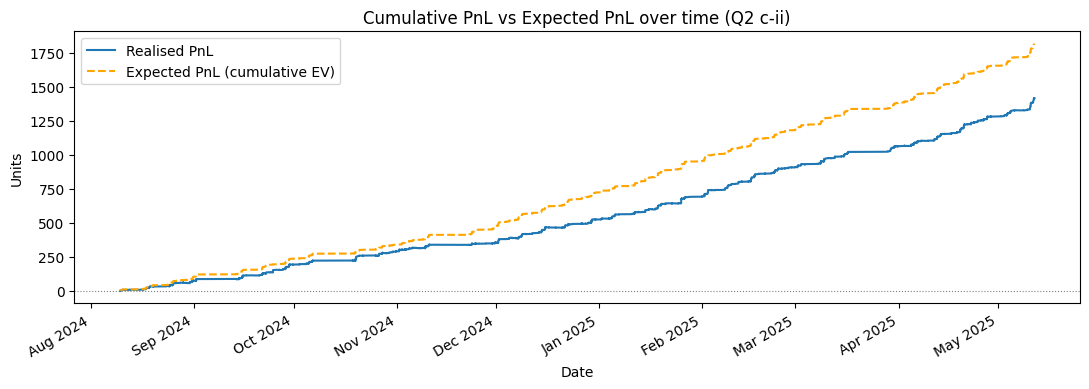

Saved q2_cumulative_pnl.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(selected['date_time'], selected['cum_pnl'], label='Realised PnL', linewidth=1.5)
ax.plot(selected['date_time'], selected['cum_ev'],  label='Expected PnL (cumulative EV)',
        linewidth=1.5, linestyle='--', color='orange')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_title('Cumulative PnL vs Expected PnL over time (Q2 c-ii)')
ax.set_xlabel('Date')
ax.set_ylabel('Units')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig('q2_cumulative_pnl.png', dpi=150)
plt.show()
print("Saved q2_cumulative_pnl.png")


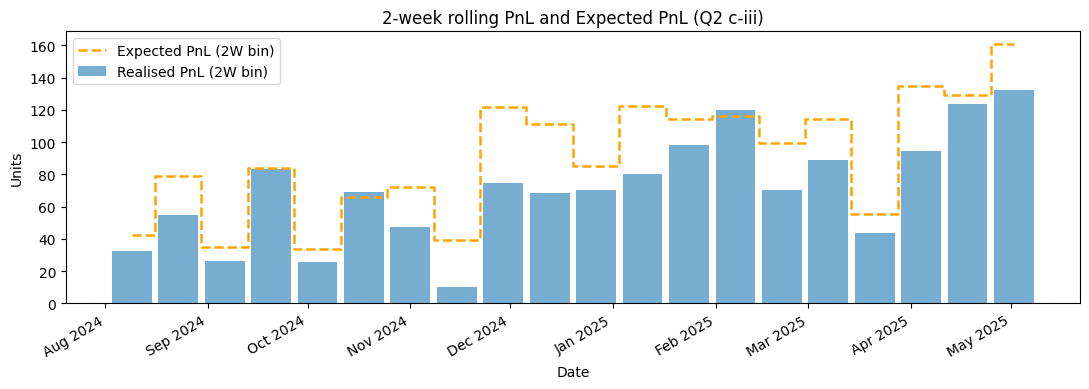

Saved q2_rolling_pnl.png


In [7]:
# Resample to 2-week bins
sel_ts = selected.copy()
sel_ts['date_time'] = pd.to_datetime(sel_ts['date_time'])
sel_ts = sel_ts.set_index('date_time').sort_index()
roll_pnl = sel_ts['pnl'].resample('14D').sum()
roll_ev  = (sel_ts['ev'] * STAKE).resample('14D').sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(roll_pnl.index, roll_pnl.values, width=12, alpha=0.6, label='Realised PnL (2W bin)')
ax.step(roll_ev.index, roll_ev.values, where='mid', color='orange',
        linewidth=1.8, linestyle='--', label='Expected PnL (2W bin)')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_title('2-week rolling PnL and Expected PnL (Q2 c-iii)')
ax.set_xlabel('Date')
ax.set_ylabel('Units')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig('q2_rolling_pnl.png', dpi=150)
plt.show()
print("Saved q2_rolling_pnl.png")


Monte Carlo (10,000 simulations, 3115 bets)
  Actual total PnL  : +1414.98
  MC median PnL     : +1814.74
  MC 5th-95th pct   : [+1707.54, +1927.14]
  P(positive PnL)   : 100.00%

  Interpretation: if model EV is the true edge, we expect PnL around +1814.74
  units at the median; actual +1414.98 is within the 0th percentile of the simulated distribution.


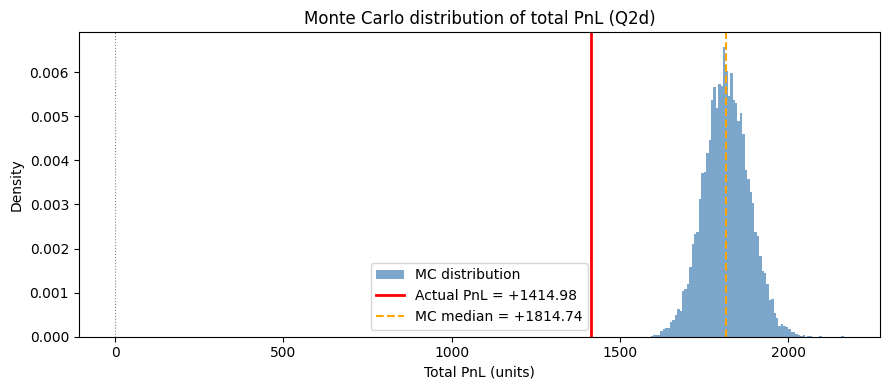

Saved q2_monte_carlo.png


In [8]:
N_SIM = 10_000
rng = np.random.default_rng(42)

p_win_arr = selected['p_model'].values     # shape (n_bets,)
odds_arr  = selected['odds'].values
n_bets_mc = len(p_win_arr)

# Simulate: shape (N_SIM, n_bets)
won_sim = rng.random((N_SIM, n_bets_mc)) < p_win_arr[None, :]
pnl_sim = np.where(won_sim, STAKE * (odds_arr[None, :] - 1), -STAKE)
cum_pnl_sim = pnl_sim.cumsum(axis=1)   # (N_SIM, n_bets) running PnL

final_pnl_sim = cum_pnl_sim[:, -1]

p5, p25, p50, p75, p95 = np.percentile(final_pnl_sim, [5, 25, 50, 75, 95])
prob_positive = (final_pnl_sim > 0).mean()
actual_pnl = total_pnl

print(f"Monte Carlo ({N_SIM:,} simulations, {n_bets_mc} bets)")
print(f"  Actual total PnL  : {actual_pnl:+.2f}")
print(f"  MC median PnL     : {p50:+.2f}")
print(f"  MC 5th-95th pct   : [{p5:+.2f}, {p95:+.2f}]")
print(f"  P(positive PnL)   : {prob_positive:.2%}")
print()
print(f"  Interpretation: if model EV is the true edge, we expect PnL around {p50:+.2f}")
print(f"  units at the median; actual {actual_pnl:+.2f} is within the ", end='')
pctile_actual = (final_pnl_sim <= actual_pnl).mean() * 100
print(f"{pctile_actual:.0f}th percentile of the simulated distribution.")

# Plot distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(final_pnl_sim, bins=80, density=True, alpha=0.7, color='steelblue', label='MC distribution')
ax.axvline(actual_pnl, color='red',    linewidth=2, label=f'Actual PnL = {actual_pnl:+.2f}')
ax.axvline(p50,        color='orange', linewidth=1.5, linestyle='--', label=f'MC median = {p50:+.2f}')
ax.axvline(0,          color='grey',   linewidth=0.8, linestyle=':')
ax.set_title('Monte Carlo distribution of total PnL (Q2d)')
ax.set_xlabel('Total PnL (units)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('q2_monte_carlo.png', dpi=150)
plt.show()
print("Saved q2_monte_carlo.png")
